In [ ]:
# Notebook 03 – Classical Machine Learning Models

## Objective

This notebook develops and evaluates three classical machine learning models for binary heart disease prediction.

The following models are implemented:

- Logistic Regression
- Random Forest
- XGBoost

Each model is evaluated using the same training and testing datasets to ensure a fair comparison.

Performance is assessed using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Cross-validation is also performed to evaluate model stability and reduce the likelihood of overfitting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed"

MODEL_PATH = PROJECT_ROOT / "models"

RESULTS_PATH = PROJECT_ROOT / "results"

FIGURES_PATH = PROJECT_ROOT / "Figures"

RESULTS_PATH.mkdir(exist_ok=True)

FIGURES_PATH.mkdir(exist_ok=True)

In [3]:
train_df = pd.read_csv(
    DATA_PATH / "heart_train_processed.csv"
)

test_df = pd.read_csv(
    DATA_PATH / "heart_test_processed.csv"
)

print(train_df.shape)

print(test_df.shape)

(242, 14)
(61, 14)


In [4]:
X_train = train_df.drop("target", axis=1)

y_train = train_df["target"]

X_test = test_df.drop("target", axis=1)

y_test = test_df["target"]

print(X_train.shape)

print(X_test.shape)

(242, 13)
(61, 13)


In [ ]:
## Logistic Regression

Logistic Regression is selected as the baseline classifier because of its simplicity, interpretability,
and widespread use in clinical prediction studies.

Its performance provides a benchmark against which more complex ensemble and boosting methods can be compared.

In [5]:
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
## Logistic Regression Evaluation

The trained Logistic Regression model is evaluated on the independent testing dataset.

Multiple evaluation metrics are reported because accuracy alone is insufficient for assessing clinical prediction models.
Precision, Recall, F1-score and ROC-AUC provide a more comprehensive assessment of predictive performance.

In [6]:
# Make predictions

y_pred = log_reg.predict(X_test)

y_prob = log_reg.predict_proba(X_test)[:, 1]

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1 Score : 0.8667
ROC AUC  : 0.9513


In [ ]:
### Interpretation

The Logistic Regression model achieved an accuracy of **86.89%** and an ROC-AUC score of **0.9513**,
indicating excellent discrimination between patients with and without heart disease.

The model demonstrated particularly high recall (92.86%), suggesting that it successfully identified
the majority of patients with heart disease. From a clinical perspective, this is desirable because failing
to detect a patient with heart disease (false negative) may have more serious consequences than incorrectly
identifying a healthy patient as being at risk.

Although the precision (81.25%) was lower than the recall, the overall F1-score of 86.67% indicates a well-balanced
classifier suitable as a baseline model for comparison with more advanced machine learning algorithms.

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



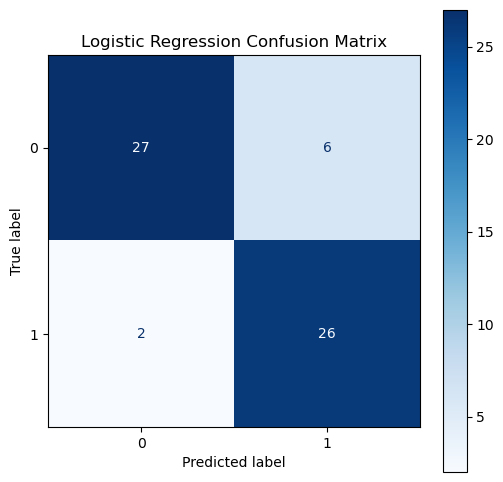

In [9]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig(
    FIGURES_PATH / "logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

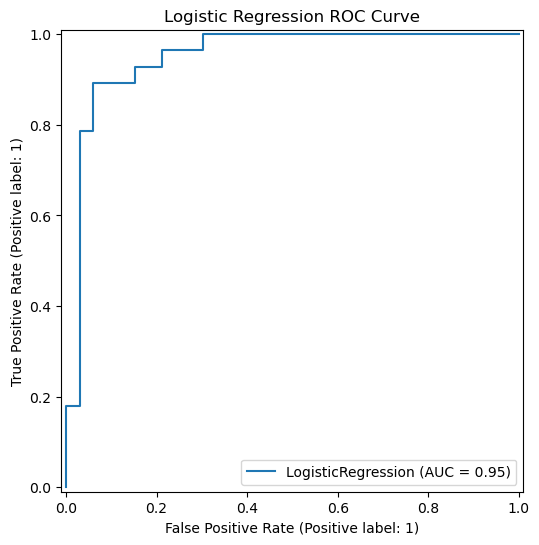

In [10]:
fig, ax = plt.subplots(figsize=(6,6))

RocCurveDisplay.from_estimator(
    log_reg,
    X_test,
    y_test,
    ax=ax
)

plt.title("Logistic Regression ROC Curve")

plt.savefig(
    FIGURES_PATH / "logistic_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
cv_scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(cv_scores)

print()

print("Mean CV Accuracy:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

[0.91836735 0.7755102  0.83333333 0.83333333 0.77083333]

Mean CV Accuracy: 0.8262755102040817
Standard Deviation: 0.053350695233877525


In [12]:
joblib.dump(
    log_reg,
    MODEL_PATH / "logistic_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between clinical variables without
requiring explicit feature engineering.

The model is evaluated using the same testing dataset and performance metrics to ensure a fair comparison.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [14]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [15]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC  : {rf_auc:.4f}")

Accuracy : 0.9180
Precision: 0.8710
Recall   : 0.9643
F1 Score : 0.9153
ROC AUC  : 0.9535


In [16]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



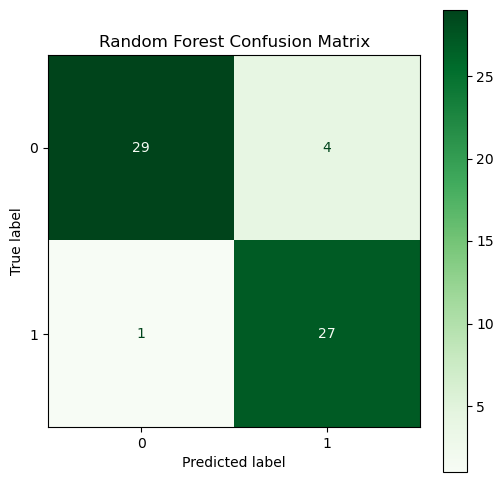

In [17]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Greens",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    FIGURES_PATH / "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

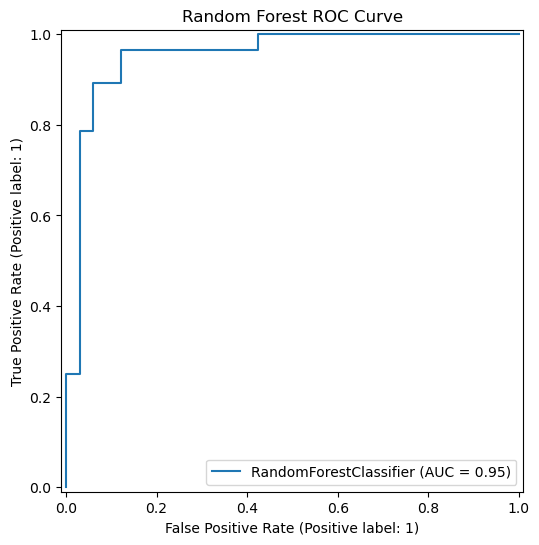

In [18]:
fig, ax = plt.subplots(figsize=(6,6))

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    ax=ax
)

plt.title("Random Forest ROC Curve")

plt.savefig(
    FIGURES_PATH / "random_forest_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(rf_cv)

print()

print("Mean CV Accuracy:", rf_cv.mean())

print("Standard Deviation:", rf_cv.std())

[0.87755102 0.7755102  0.83333333 0.75       0.79166667]

Mean CV Accuracy: 0.8056122448979591
Standard Deviation: 0.04502661426768139


In [20]:
joblib.dump(
    rf,
    MODEL_PATH / "random_forest.pkl"
)

print("Random Forest model saved.")

Random Forest model saved.


In [ ]:
### Interpretation

The Random Forest classifier was evaluated using the independent testing dataset.

Compared with Logistic Regression, Random Forest is expected to better capture complex non-linear relationships among clinical variables.
Performance is assessed using multiple evaluation metrics to determine whether the increased model complexity results in improved predictive capability.

The results will later be compared with Logistic Regression, XGBoost and the Deep Neural Network to determine the most suitable model
for early heart disease prediction.

In [ ]:
### Interpretation

The Random Forest classifier achieved an accuracy of **91.80%** and an ROC-AUC score of **0.9535**,
outperforming the Logistic Regression baseline across all primary evaluation metrics.

The model achieved a recall of **96.43%**, indicating that it correctly identified almost all patients with heart disease.
This is particularly important in clinical decision support, where failing to detect a patient with disease may have serious consequences.

Compared with Logistic Regression, Random Forest demonstrated improved predictive performance while maintaining excellent discrimination ability.
These findings suggest that modelling non-linear relationships between clinical variables provides measurable benefits for heart disease prediction.

In [ ]:
## XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is an ensemble learning algorithm based on gradient-boosted decision trees.

It has become one of the most successful algorithms for structured and tabular datasets due to its ability
to model complex non-linear relationships while incorporating regularisation techniques to reduce overfitting.

The model is evaluated using the same experimental protocol as the previous classifiers to ensure a fair comparison.

In [21]:
from xgboost import XGBClassifier

In [22]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [23]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [24]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC AUC  : {xgb_auc:.4f}")

Accuracy : 0.8852
Precision: 0.8182
Recall   : 0.9643
F1 Score : 0.8852
ROC AUC  : 0.9470


In [25]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



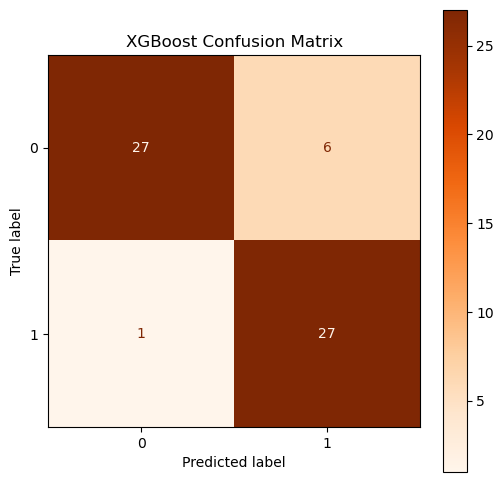

In [26]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    cmap="Oranges",
    ax=ax
)

plt.title("XGBoost Confusion Matrix")

plt.savefig(
    FIGURES_PATH / "xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

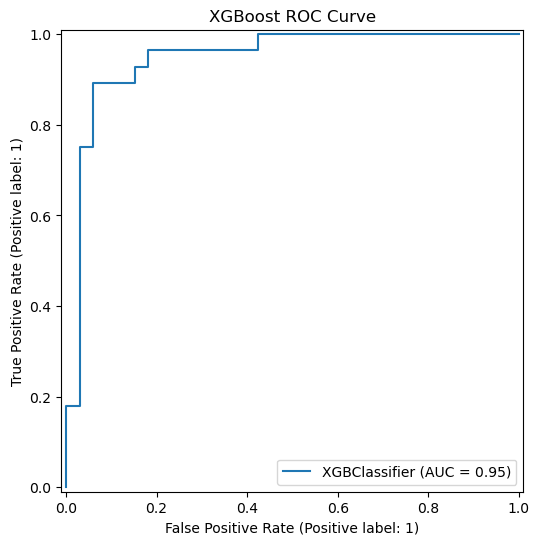

In [27]:
fig, ax = plt.subplots(figsize=(6,6))

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    ax=ax
)

plt.title("XGBoost ROC Curve")

plt.savefig(
    FIGURES_PATH / "xgboost_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
xgb_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(xgb_cv)

print()

print("Mean CV Accuracy:", xgb_cv.mean())

print("Standard Deviation:", xgb_cv.std())

[0.85714286 0.79591837 0.8125     0.72916667 0.79166667]

Mean CV Accuracy: 0.7972789115646257
Standard Deviation: 0.041201941196388876


In [29]:
joblib.dump(
    xgb,
    MODEL_PATH / "xgboost.pkl"
)

print("XGBoost model saved.")

XGBoost model saved.


In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC AUC": [
        roc_auc,
        rf_auc,
        xgb_auc
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9535
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9470


In [31]:
results.to_csv(
    RESULTS_PATH / "classical_ml_results.csv",
    index=False
)

print("Results table saved successfully.")

Results table saved successfully.
